In [29]:
import slangpy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os 
cwd = Path(os.getcwd())

In [30]:
device = slangpy.create_device(slangpy.DeviceType.vulkan)
program = (cwd / "CSPrecompute.slang").as_posix()    

integrateGGX_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_E"]))    
integrateGGX_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_Eavg"]))

ggx_E = device.create_buffer(element_count=32*32, struct_size=8, format=slangpy.Format.rg32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_Eavg = device.create_buffer(element_count=32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)

integrateGGX_E.dispatch(thread_count=[1,1,1],vars={"ggxE": ggx_E})
integrateGGX_Eavg.dispatch(thread_count=[1,1,1],vars={"ggxEavg": ggx_Eavg})

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] Slang compiler warnings:
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'wt'
        return false;
        ^~~~~~
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'etap'
        return false;
        ^~~~~~



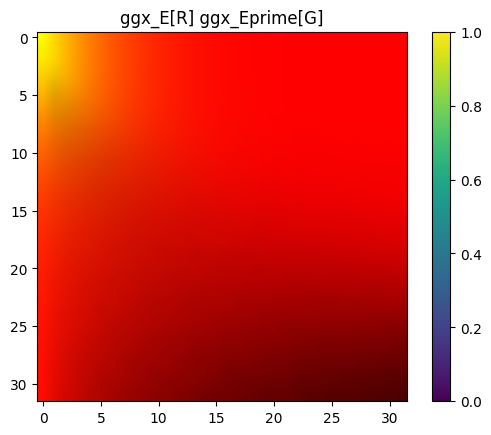

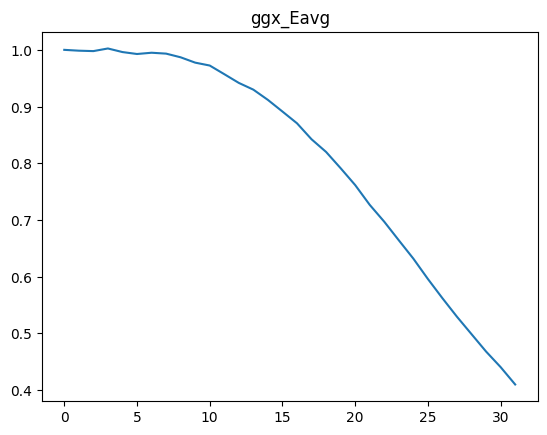

In [31]:
# E
im_ggx_E = ggx_E.to_numpy().reshape(32, 32, 2)
im_ggx_E = np.dstack([im_ggx_E, np.zeros((32, 32, 1), dtype=im_ggx_E.dtype)])
plt.imshow(im_ggx_E, interpolation='bilinear')
plt.title('ggx_E[R] ggx_Eprime[G]')
plt.colorbar()
plt.show()
# Eavg
im_ggx_Eavg = ggx_Eavg.to_numpy()
plt.plot(im_ggx_Eavg)
plt.title('ggx_Eavg')
plt.show()


In [ ]:
# Dump it.
# We don't use image containers for this as this would be uploaded back to GPU anyway
print("// Generated by Scripts/CSPrecompute.ipynb")
print("constexpr float /* RG32 */ kGGXlutE[32 * 32 * 2] = {\n\t",end='')
for i, v in enumerate(ggx_E.to_numpy().flatten()):
    print(f"{v:.6f}f,", end=' ' if (i+1) % 32 else '\n\t')
print("\n};")

// Generated by Scripts/CSPrecompute.ipynb
constexpr float kGGXlutE[32 * 32 * 2] = {
	1.000000f, 0.999511f, 1.000000f, 0.848810f, 1.000000f, 0.716469f, 1.000000f, 0.601152f, 1.000000f, 0.501215f, 1.000000f, 0.415030f, 1.000000f, 0.341101f, 1.000000f, 0.278130f, 1.000000f, 0.224809f, 1.000000f, 0.180010f, 1.000000f, 0.142659f, 1.000000f, 0.111778f, 1.000000f, 0.086487f, 1.000000f, 0.065999f, 1.000000f, 0.049592f, 1.000000f, 0.036626f,
	1.000000f, 0.026525f, 1.000000f, 0.018786f, 1.000000f, 0.012970f, 1.000000f, 0.008692f, 1.000000f, 0.005625f, 1.000000f, 0.003493f, 1.000000f, 0.002062f, 1.000000f, 0.001145f, 1.000000f, 0.000587f, 1.000000f, 0.000272f, 1.000000f, 0.000109f, 1.000000f, 0.000036f, 1.000000f, 0.000008f, 1.000000f, 0.000001f, 1.000000f, 0.000000f, 1.000000f, 0.000000f,
	0.979945f, 0.953117f, 0.999252f, 0.847746f, 0.999909f, 0.716202f, 0.999996f, 0.600926f, 0.999997f, 0.501071f, 0.999999f, 0.414928f, 0.999756f, 0.340950f, 1.000000f, 0.278063f, 1.000000f, 0.224832f, 1.000000f,

In [ ]:
print("constexpr float /* R32 */ kGGXlutEavg[32] = {\n\t",end='')
for v in ggx_Eavg.to_numpy():
    print(f"{v:.6f}f,", end=' ')
print("\n};")

constexpr float kGGXlutEavg[32] = {
	1.000354f, 0.998875f, 0.998133f, 1.002769f, 0.996455f, 0.993020f, 0.995248f, 0.993688f, 0.987193f, 0.977785f, 0.972672f, 0.957444f, 0.942013f, 0.930101f, 0.912021f, 0.891485f, 0.870754f, 0.842554f, 0.820199f, 0.791489f, 0.761750f, 0.726832f, 0.697052f, 0.664273f, 0.631912f, 0.595987f, 0.562018f, 0.529314f, 0.498607f, 0.467945f, 0.440478f, 0.409852f, 
};
